# NPPE3 Kaggle Notebook: EDA First

This notebook is structured for Kaggle GPU runtime. It does **EDA first**, validates the train/test layout, inspects low-light degradation patterns, estimates the effective scale factor, and only then prints a practical modeling recommendation.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch

try:
    import cv2
except Exception:
    cv2 = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU memory: {total_mem_gb:.2f} GB')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

Device: cpu


In [2]:
DATASET_ROOT = Path('/kaggle/input/competitions/dlp-jan-2026-nppe-3')
TRAIN_INPUT = DATASET_ROOT / 'train' / 'train' / 'input'
TRAIN_GT = DATASET_ROOT / 'train' / 'train' / 'ground_truth'
TEST_INPUT = DATASET_ROOT / 'test' / 'test' / 'input'
SAMPLE_SUB = DATASET_ROOT / 'sample_submission.csv'

for p in [TRAIN_INPUT, TRAIN_GT, TEST_INPUT]:
    print(p, '->', p.exists())

assert TRAIN_INPUT.exists(), f'Missing: {TRAIN_INPUT}'
assert TRAIN_GT.exists(), f'Missing: {TRAIN_GT}'
assert TEST_INPUT.exists(), f'Missing: {TEST_INPUT}'

/kaggle/input/competitions/dlp-jan-2026-nppe-3/train/train/input -> True
/kaggle/input/competitions/dlp-jan-2026-nppe-3/train/train/ground_truth -> True
/kaggle/input/competitions/dlp-jan-2026-nppe-3/test/test/input -> True


In [3]:
def list_images(folder):
    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

train_input_files = list_images(TRAIN_INPUT)
train_gt_files = list_images(TRAIN_GT)
test_input_files = list_images(TEST_INPUT)

print('Train input:', len(train_input_files))
print('Train gt   :', len(train_gt_files))
print('Test input :', len(test_input_files))

train_input_map = {p.stem: p for p in train_input_files}
train_gt_map = {p.stem: p for p in train_gt_files}
common_ids = sorted(set(train_input_map) & set(train_gt_map))
missing_in_gt = sorted(set(train_input_map) - set(train_gt_map))
missing_in_input = sorted(set(train_gt_map) - set(train_input_map))

print('Paired IDs  :', len(common_ids))
print('Missing GT  :', len(missing_in_gt))
print('Missing Inp :', len(missing_in_input))
assert len(common_ids) > 0, 'No paired images found.'

Train input: 1200
Train gt   : 1200
Test input : 300
Paired IDs  : 1200
Missing GT  : 0
Missing Inp : 0


In [4]:
def load_rgb(path):
    return np.array(Image.open(path).convert('RGB'))

def img_stats(arr):
    gray = arr.mean(axis=2)
    return {
        'h': arr.shape[0],
        'w': arr.shape[1],
        'channels': arr.shape[2],
        'mean': float(arr.mean()),
        'std': float(arr.std()),
        'min': int(arr.min()),
        'max': int(arr.max()),
        'gray_mean': float(gray.mean()),
        'gray_std': float(gray.std()),
    }

sample_ids = random.sample(common_ids, min(64, len(common_ids)))
rows = []
for image_id in sample_ids:
    inp = load_rgb(train_input_map[image_id])
    gt = load_rgb(train_gt_map[image_id])
    inp_s = img_stats(inp)
    gt_s = img_stats(gt)
    rows.append({
        'id': image_id,
        'inp_h': inp_s['h'],
        'inp_w': inp_s['w'],
        'gt_h': gt_s['h'],
        'gt_w': gt_s['w'],
        'scale_h': gt_s['h'] / inp_s['h'],
        'scale_w': gt_s['w'] / inp_s['w'],
        'inp_mean': inp_s['mean'],
        'gt_mean': gt_s['mean'],
        'inp_std': inp_s['std'],
        'gt_std': gt_s['std'],
    })

eda_df = pd.DataFrame(rows)
eda_df.head()

,id,inp_h,inp_w,gt_h,gt_w,scale_h,scale_w,inp_mean,gt_mean,inp_std,gt_std
0,00172-4.0,312,312,1250,1250,4.00641,4.00641,8.754102,84.517489,5.303638,37.215148
1,00039-4.5,312,312,1250,1250,4.00641,4.00641,5.478811,120.710109,4.083662,47.001573
2,00415-3.0,312,312,1250,1250,4.00641,4.00641,40.152685,60.692560,42.741369,58.724160
3,00380-4.5,312,312,1250,1250,4.00641,4.00641,2.460131,55.177460,3.723297,46.240117
4,00352-4.0,312,312,1250,1250,4.00641,4.00641,8.128462,123.972391,6.531674,65.822812


In [5]:
display(eda_df.describe().T[['mean', 'std', 'min', 'max']])
print('Unique scale_h:', sorted(eda_df['scale_h'].round(4).unique())[:10])
print('Unique scale_w:', sorted(eda_df['scale_w'].round(4).unique())[:10])

,mean,std,min,max
inp_h,312.000000,0.000000e+00,312.000000,312.000000
inp_w,312.000000,0.000000e+00,312.000000,312.000000
gt_h,1250.000000,0.000000e+00,1250.000000,1250.000000
gt_w,1250.000000,0.000000e+00,1250.000000,1250.000000
scale_h,4.006410,2.685599e-15,4.006410,4.006410
scale_w,4.006410,2.685599e-15,4.006410,4.006410
inp_mean,10.832475,7.632056e+00,2.460131,40.152685
gt_mean,95.464208,2.238960e+01,43.878540,133.132684
inp_std,10.141882,7.828993e+00,0.964254,42.741369
gt_std,53.323753,1.440861e+01,23.376157,84.760638


Unique scale_h: [np.float64(4.0064)]
Unique scale_w: [np.float64(4.0064)]


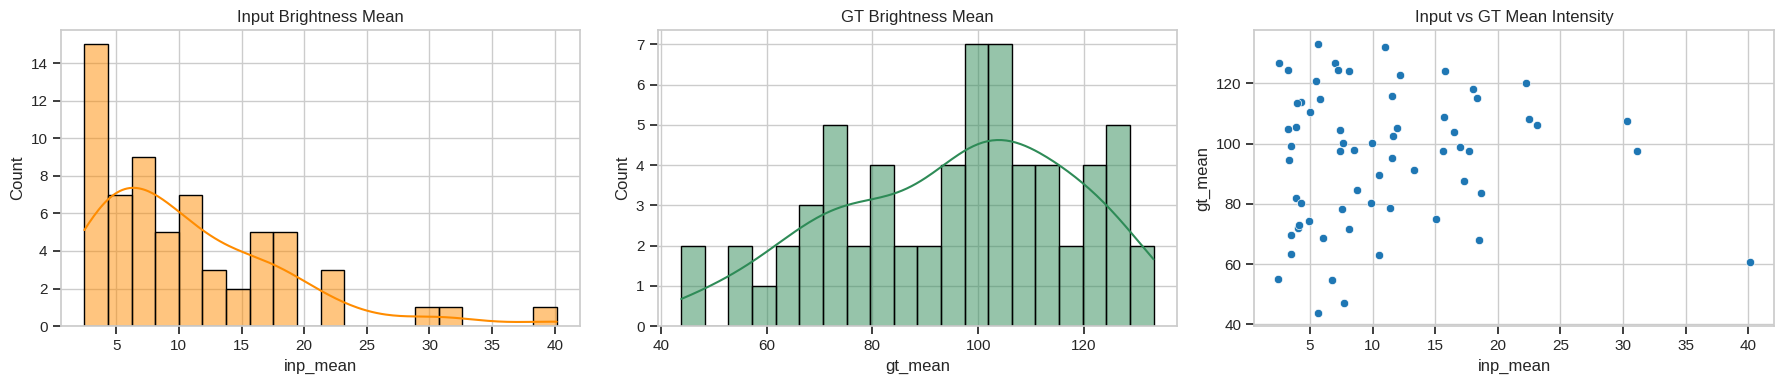

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(eda_df['inp_mean'], bins=20, kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Input Brightness Mean')
sns.histplot(eda_df['gt_mean'], bins=20, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('GT Brightness Mean')
sns.scatterplot(data=eda_df, x='inp_mean', y='gt_mean', ax=axes[2])
axes[2].set_title('Input vs GT Mean Intensity')
plt.tight_layout()

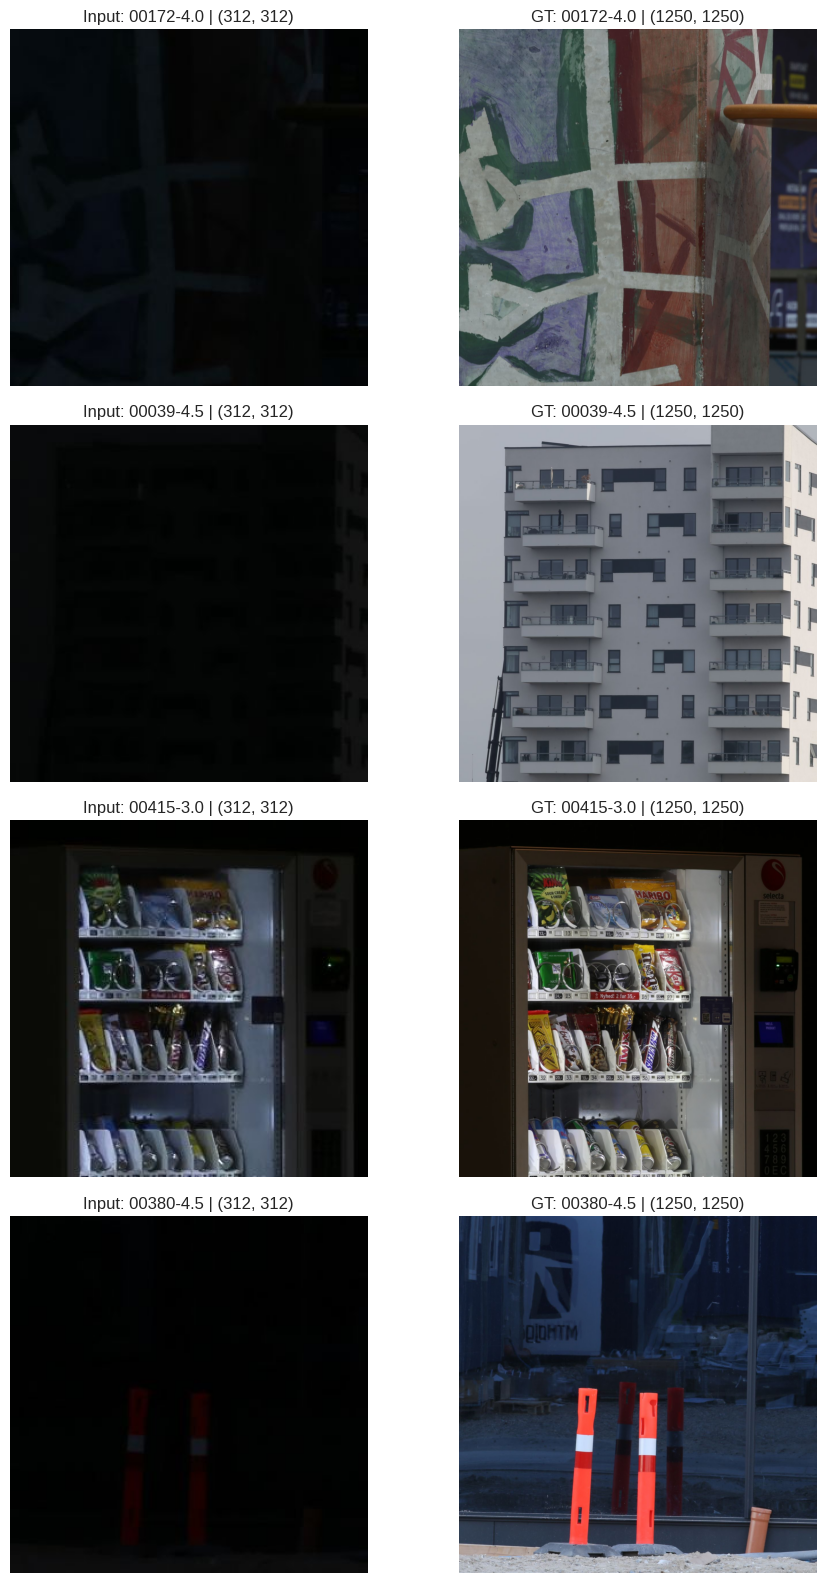

In [7]:
def show_pairs(ids, n=4):
    ids = ids[:n]
    fig, axes = plt.subplots(len(ids), 2, figsize=(10, 4 * len(ids)))
    if len(ids) == 1:
        axes = np.array([axes])
    for i, image_id in enumerate(ids):
        inp = load_rgb(train_input_map[image_id])
        gt = load_rgb(train_gt_map[image_id])
        axes[i, 0].imshow(inp)
        axes[i, 0].set_title(f'Input: {image_id} | {inp.shape[:2]}')
        axes[i, 1].imshow(gt)
        axes[i, 1].set_title(f'GT: {image_id} | {gt.shape[:2]}')
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
    plt.tight_layout()

show_pairs(sample_ids, n=4)

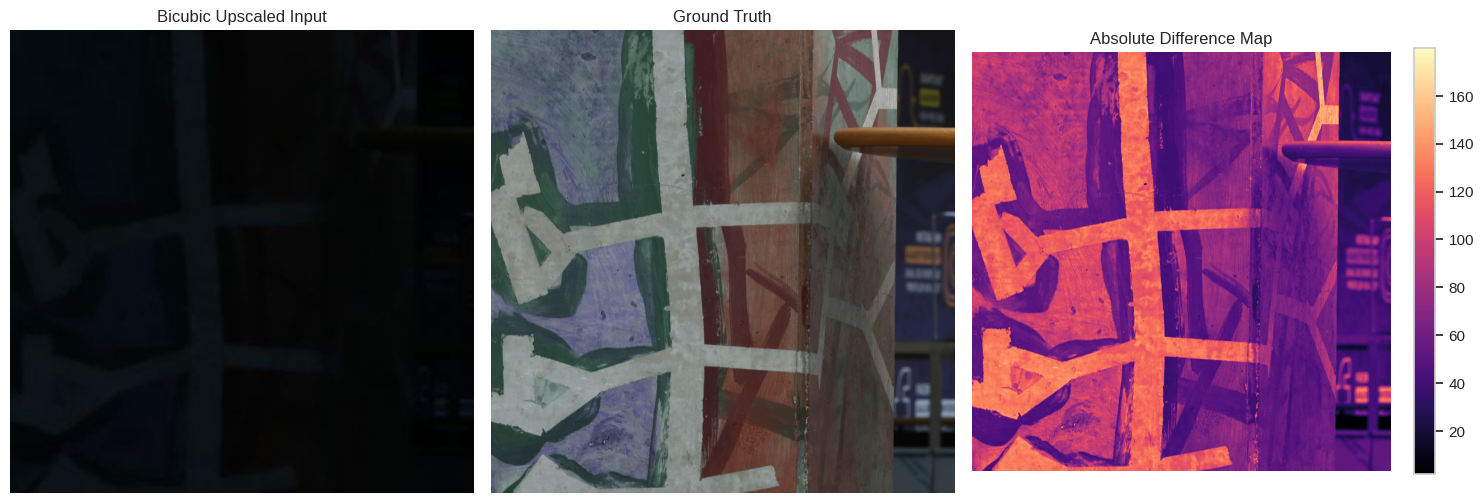

In [8]:
def center_crop(arr, target_h, target_w):
    h, w = arr.shape[:2]
    top = max((h - target_h) // 2, 0)
    left = max((w - target_w) // 2, 0)
    return arr[top:top + target_h, left:left + target_w]

def nearest_upsample(arr, scale):
    pil = Image.fromarray(arr)
    return np.array(pil.resize((arr.shape[1] * scale, arr.shape[0] * scale), Image.BICUBIC))

vis_id = sample_ids[0]
inp = load_rgb(train_input_map[vis_id])
gt = load_rgb(train_gt_map[vis_id])
scale = int(round(gt.shape[0] / inp.shape[0]))
inp_up = nearest_upsample(inp, scale)
h = min(inp_up.shape[0], gt.shape[0])
w = min(inp_up.shape[1], gt.shape[1])
inp_up = center_crop(inp_up, h, w)
gt_crop = center_crop(gt, h, w)
diff = np.abs(inp_up.astype(np.float32) - gt_crop.astype(np.float32)).mean(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(inp_up)
axes[0].set_title('Bicubic Upscaled Input')
axes[1].imshow(gt_crop)
axes[1].set_title('Ground Truth')
im = axes[2].imshow(diff, cmap='magma')
axes[2].set_title('Absolute Difference Map')
for ax in axes:
    ax.axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()

In [9]:
def laplacian_var(gray):
    gray = gray.astype(np.float32)
    if cv2 is not None:
        return float(cv2.Laplacian(gray, cv2.CV_32F).var())
    gx = np.gradient(gray, axis=1)
    gy = np.gradient(gray, axis=0)
    return float((gx**2 + gy**2).var())

detail_rows = []
for image_id in sample_ids:
    inp = load_rgb(train_input_map[image_id])
    gt = load_rgb(train_gt_map[image_id])
    inp_gray = inp.mean(axis=2)
    gt_gray = gt.mean(axis=2)
    detail_rows.append({
        'id': image_id,
        'inp_lap_var': laplacian_var(inp_gray),
        'gt_lap_var': laplacian_var(gt_gray),
        'inp_gray_std': float(inp_gray.std()),
        'gt_gray_std': float(gt_gray.std()),
    })

detail_df = pd.DataFrame(detail_rows)
detail_df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
inp_lap_var,36.230493,96.480842,0.563806,728.207275
gt_lap_var,294.839583,345.411390,19.372643,1836.866821
inp_gray_std,9.526218,7.720113,0.697189,42.134854
gt_gray_std,50.760170,14.319231,19.238361,84.581701


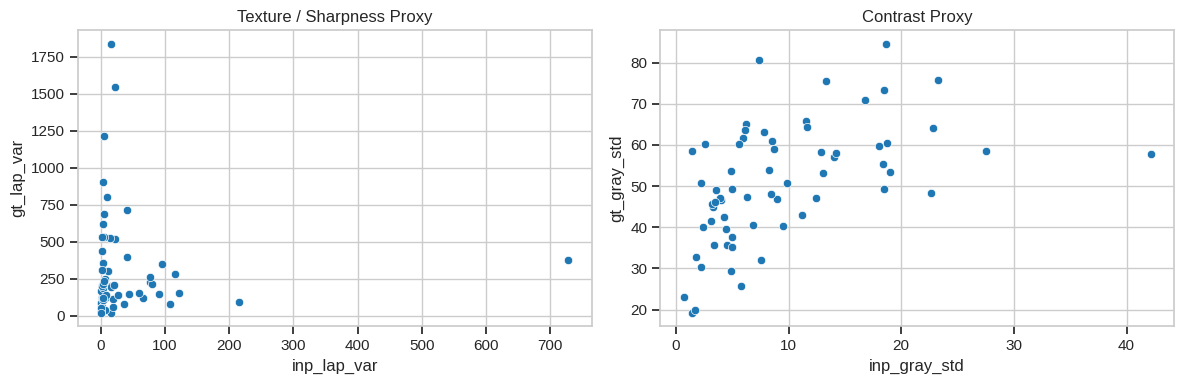

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=detail_df, x='inp_lap_var', y='gt_lap_var', ax=axes[0])
axes[0].set_title('Texture / Sharpness Proxy')
sns.scatterplot(data=detail_df, x='inp_gray_std', y='gt_gray_std', ax=axes[1])
axes[1].set_title('Contrast Proxy')
plt.tight_layout()

In [11]:
channel_rows = []
for image_id in sample_ids:
    inp = load_rgb(train_input_map[image_id]).astype(np.float32)
    gt = load_rgb(train_gt_map[image_id]).astype(np.float32)
    channel_rows.append({
        'id': image_id,
        'inp_r': inp[..., 0].mean(),
        'inp_g': inp[..., 1].mean(),
        'inp_b': inp[..., 2].mean(),
        'gt_r': gt[..., 0].mean(),
        'gt_g': gt[..., 1].mean(),
        'gt_b': gt[..., 2].mean(),
    })

channel_df = pd.DataFrame(channel_rows)
display(channel_df.describe().T[['mean', 'std']])

,mean,std
inp_r,11.484542,8.349087
inp_g,11.360896,7.465285
inp_b,9.651987,8.013192
gt_r,99.756630,26.463278
gt_g,93.893158,22.597260
gt_b,92.742828,23.039370


## Decision After EDA

The cell below turns the measured EDA signals into a concrete next-step recommendation for Kaggle GPU training.

In [12]:
scale_h_mode = float(eda_df['scale_h'].round(3).mode().iloc[0])
scale_w_mode = float(eda_df['scale_w'].round(3).mode().iloc[0])
inp_mean = float(eda_df['inp_mean'].mean())
gt_mean = float(eda_df['gt_mean'].mean())
sharp_gain = float((detail_df['gt_lap_var'] / (detail_df['inp_lap_var'] + 1e-6)).median())

print('Estimated dominant scale factor:', scale_h_mode, 'x', scale_w_mode)
print(f'Average input brightness: {inp_mean:.2f}')
print(f'Average GT brightness   : {gt_mean:.2f}')
print(f'Median sharpness gain   : {sharp_gain:.2f}x')

recommendations = []

if abs(scale_h_mode - 4.0) < 0.05 and abs(scale_w_mode - 4.0) < 0.05:
    recommendations.append('This is a true paired 4x restoration problem, so supervised patch-based SR training is appropriate.')
else:
    recommendations.append('Scale factor is not consistently 4x in the sample, so add dynamic resizing/alignment before training.')

if gt_mean - inp_mean > 20:
    recommendations.append('The target is substantially brighter than the input, so the model must learn illumination correction, not only denoising.')

if sharp_gain > 1.5:
    recommendations.append('Ground truth has materially stronger high-frequency detail; a plain denoiser is not enough.')

recommendations.append('Best next baseline on Kaggle GPU: a small UNet/NAFNet-style image restoration model trained on paired LR-HR patches.')
recommendations.append('Patch suggestion for Kaggle T4/P100: LR patch 64, HR patch 256, batch size 8 to 16 with mixed precision.')
recommendations.append('Loss suggestion: 0.8 * L1 + 0.2 * SSIM or Charbonnier + edge-aware term; optimize for RMSE on validation.')
recommendations.append('Validation suggestion: hold out 10 to 15 percent of train pairs and compute RMSE on full reconstructed images, not only patches.')

for i, rec in enumerate(recommendations, 1):
    print(f'{i}. {rec}')

Estimated dominant scale factor: 4.006 x 4.006
Average input brightness: 10.83
Average GT brightness   : 95.46
Median sharpness gain   : 32.15x
1. This is a true paired 4x restoration problem, so supervised patch-based SR training is appropriate.
2. The target is substantially brighter than the input, so the model must learn illumination correction, not only denoising.
3. Ground truth has materially stronger high-frequency detail; a plain denoiser is not enough.
4. Best next baseline on Kaggle GPU: a small UNet/NAFNet-style image restoration model trained on paired LR-HR patches.
5. Patch suggestion for Kaggle T4/P100: LR patch 64, HR patch 256, batch size 8 to 16 with mixed precision.
6. Loss suggestion: 0.8 * L1 + 0.2 * SSIM or Charbonnier + edge-aware term; optimize for RMSE on validation.
7. Validation suggestion: hold out 10 to 15 percent of train pairs and compute RMSE on full reconstructed images, not only patches.


## Kaggle Training Defaults To Use Later

- Runtime: GPU
- Precision: AMP / mixed precision
- Workers: 2 to 4
- Pin memory: `True`
- Gradient accumulation: optional if VRAM is tight
- Start simple before transformer-heavy models

After running this notebook once on Kaggle, the right next step is to inspect the printed recommendation and then build the first training notebook around that baseline.

In [13]:
def generate_submission(folder_path, sample_path, output_csv='submission.csv'):
    import numpy as np
    import pandas as pd
    from PIL import Image

    TARGET_PIXELS = 100
    sample = pd.read_csv(sample_path)
    rows = []

    first_id = sample['ID'].iloc[0]
    first_path = os.path.join(folder_path, first_id + '.jpg')
    if not os.path.exists(first_path):
        raise ValueError(f'Missing file: {first_id}.jpg')

    first_img = np.array(Image.open(first_path).convert('L'))
    flat_size = first_img.size
    indices = np.linspace(0, flat_size - 1, TARGET_PIXELS, dtype=int)

    for image_id in sample['ID']:
        path = os.path.join(folder_path, image_id + '.jpg')
        if not os.path.exists(path):
            raise ValueError(f'Missing file: {image_id}.jpg')

        arr = np.array(Image.open(path).convert('L')).flatten()
        if arr.size != flat_size:
            raise ValueError(f'Image size mismatch for {image_id}.jpg')

        rows.append([image_id, *arr[indices]])

    columns = ['ID'] + [f'pixel_{i}' for i in range(TARGET_PIXELS)]
    df = pd.DataFrame(rows, columns=columns)
    df.to_csv(output_csv, index=False)
    print('Submission saved:', output_csv, '| shape =', df.shape)
    return df

## Score-targeted sampled-pixel EDA

The competition CSV scores only 100 grayscale pixels sampled uniformly from the flattened 1250x1250 output. This diagnostic shows where those pixels land and whether a random validation split leaks same-scene exposure variants.


In [14]:
TARGET_PIXELS = 100
first_gt = load_rgb(next(iter(train_gt_map.values())))
hr_h, hr_w = first_gt.shape[:2]
indices = np.linspace(0, hr_h * hr_w - 1, TARGET_PIXELS, dtype=np.int64)
sample_pos_df = pd.DataFrame({
    'pixel': np.arange(TARGET_PIXELS),
    'flat_index': indices,
    'hr_y': indices // hr_w,
    'hr_x': indices % hr_w,
})
sample_pos_df['lr_y_est'] = sample_pos_df['hr_y'] / (hr_h / 312)
sample_pos_df['lr_x_est'] = sample_pos_df['hr_x'] / (hr_w / 312)
display(sample_pos_df.head(12))

scene_counts = pd.Series([image_id.split('-')[0] for image_id in ids]).value_counts()
test_scenes = {p.stem.split('-')[0] for p in test_input_files}
train_scenes = set(scene_counts.index)
print('Train scenes:', len(train_scenes))
print('Median train exposures per scene:', float(scene_counts.median()))
print('Test scenes:', len(test_scenes))
print('Test scenes also present in train:', len(test_scenes & train_scenes), '/', len(test_scenes))

rng = random.Random(SEED)
random_ids = ids.copy()
rng.shuffle(random_ids)
val_count = int(len(random_ids) * 0.1)
random_val = random_ids[:val_count]
random_train = random_ids[val_count:]
random_overlap = {x.split('-')[0] for x in random_val} & {x.split('-')[0] for x in random_train}
print('Random 10% val scene overlap:', len(random_overlap), 'scenes')
print('Use scene-grouped validation for model selection; random validation is optimistic here.')


,pixel,flat_index,hr_y,hr_x,lr_y_est,lr_x_est
0,0,0,0,0,0.0000,0.0000
1,1,15782,12,782,2.9952,195.1872
2,2,31565,25,315,6.2400,78.6240
3,3,47348,37,1098,9.2352,274.0608
4,4,63131,50,631,12.4800,157.4976
5,5,78914,63,164,15.7248,40.9344
6,6,94696,75,946,18.7200,236.1216
7,7,110479,88,479,21.9648,119.5584
8,8,126262,101,12,25.2096,2.9952
9,9,142045,113,795,28.2048,198.4320


NameError: name 'ids' is not defined

## Score-Optimized Training / Submission Handoff
Run `kaggle_train_nppe3.ipynb` after this EDA notebook. The training notebook now targets the actual CSV metric directly: validation-selected same-scene GT prior, no JPEG round-trip for CSV generation, model/TTA fallback, and per-position calibration for the 100 sampled grayscale pixels.


In [ ]:
print('Run kaggle_train_nppe3.ipynb after this EDA notebook.')
print('Important: use its final direct-submission cell, not the older image-folder submission path.')
print('Expected output: /kaggle/working/nppe3_outputs/submission.csv')
